# From Linear Regression to Multilayer Perceptron

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
FILENAME: str = "global_climate_co2_anomalies.csv"
FEATURES: list[str] = [
    "year",
    "latitude",
    "longitude",
    "population_millions",
    "population_density",
    "urbanization_rate",
    "gdp_per_capita_usd",
    "primary_energy_twh",
    "electricity_demand_twh",
    "renewable_capacity_gw",
    "share_renewables_pct",
    "share_coal_pct",
    "oil_production",
    "temp_anomaly_global",
    "temp_anomaly_land",
    "temp_anomaly_ocean",
    "temp_anomaly_arctic",
    "precipitation_anomaly",
    "drought_index_pdsi",
    "spi_3month",
    "nino34_index",
    "sea_surface_temp_anom",
    "ocean_heat_content",
    "country",
    "continent",
    "income_group",
    "latitude_band",
    "climate_zone",
]
TARGET: str = "co2_emissions"

In [3]:
df = pd.read_csv(FILENAME)[[*FEATURES, TARGET]]
df.head()

,year,latitude,longitude,population_millions,population_density,urbanization_rate,gdp_per_capita_usd,primary_energy_twh,electricity_demand_twh,renewable_capacity_gw,...,spi_3month,nino34_index,sea_surface_temp_anom,ocean_heat_content,country,continent,income_group,latitude_band,climate_zone,co2_emissions
0,1990,-34.0,-64.0,37.0,13309.4,89.0,8749.0,184.8,64.7,12.2,...,-0.13,-0.01,0.15,-5.19,Argentina,South America,Upper Middle,Temperate,Temperate,150.6
1,1990,-34.0,-64.0,37.0,13309.4,89.0,8749.0,184.8,64.7,12.2,...,0.26,0.54,0.17,-5.19,Argentina,South America,Upper Middle,Temperate,Temperate,150.6
2,1990,-34.0,-64.0,37.0,13309.4,89.0,8749.0,184.8,64.7,12.2,...,-0.57,0.51,0.26,-5.19,Argentina,South America,Upper Middle,Temperate,Temperate,150.6
3,1990,-34.0,-64.0,37.0,13309.4,89.0,8749.0,184.8,64.7,12.2,...,0.38,0.26,0.27,NaN,Argentina,South America,Upper Middle,Temperate,Temperate,150.6
4,1990,-34.0,-64.0,37.0,13309.4,89.0,8749.0,184.8,64.7,12.2,...,0.18,-0.07,NaN,-5.19,Argentina,South America,Upper Middle,Temperate,Temperate,150.6


## Data Cleaning

In [4]:
df.columns[df.isna().any()]

Index(['renewable_capacity_gw', 'sea_surface_temp_anom', 'ocean_heat_content'], dtype='str')

In [5]:
df_cleaned = df.dropna()
df_cleaned.describe()

,year,latitude,longitude,population_millions,population_density,urbanization_rate,gdp_per_capita_usd,primary_energy_twh,electricity_demand_twh,renewable_capacity_gw,...,temp_anomaly_land,temp_anomaly_ocean,temp_anomaly_arctic,precipitation_anomaly,drought_index_pdsi,spi_3month,nino34_index,sea_surface_temp_anom,ocean_heat_content,co2_emissions
count,11017.000000,11017.000000,11017.000000,11017.000000,1.101700e+04,11017.000000,11017.000000,11017.000000,11017.000000,11017.000000,...,11017.000000,11017.000000,11017.000000,11017.000000,11017.000000,11017.000000,11017.000000,11017.000000,11017.000000,11017.000000
mean,2007.478352,22.500953,39.273305,199.947098,1.716067e+05,70.649260,23512.090497,1625.087755,568.778579,382.308469,...,1.092422,0.571847,1.497165,0.315267,-0.121108,0.001681,0.369374,0.480590,18.062743,1000.850113
std,9.979505,29.659849,73.861736,363.522006,2.504387e+05,22.581138,19459.696061,2713.346929,949.671749,849.744596,...,0.324197,0.323055,0.697525,39.223010,0.832738,0.575101,1.112003,0.273934,13.174649,1774.779454
min,1990.000000,-42.000000,-102.000000,3.800000,2.470100e+03,20.500000,592.000000,16.400000,5.700000,0.500000,...,0.490000,-0.070000,-0.080000,-141.600000,-3.470000,-2.090000,-2.180000,-0.100000,-5.610000,1.900000
25%,1999.000000,9.000000,2.000000,45.600000,1.866910e+04,49.500000,6183.000000,250.100000,87.500000,31.700000,...,0.840000,0.320000,0.980000,-25.600000,-0.680000,-0.380000,-0.530000,0.270000,6.830000,234.400000
50%,2008.000000,30.000000,35.000000,84.490000,8.741400e+04,80.300000,18998.000000,567.100000,198.500000,100.700000,...,1.060000,0.540000,1.440000,0.300000,-0.110000,0.000000,0.420000,0.460000,18.610000,411.600000
75%,2016.000000,46.000000,105.000000,177.500000,2.429607e+05,88.800000,36814.000000,1776.900000,621.900000,463.800000,...,1.260000,0.730000,1.860000,26.900000,0.450000,0.380000,1.070000,0.620000,29.500000,752.600000
max,2024.000000,62.000000,172.000000,1863.450000,1.623446e+06,98.000000,88517.000000,40188.000000,14065.800000,16035.000000,...,2.160000,1.610000,3.940000,150.200000,3.150000,2.390000,3.200000,1.380000,40.400000,11348.600000


In [6]:
df_cleaned.dtypes

year                        int64
latitude                  float64
longitude                 float64
population_millions       float64
population_density        float64
urbanization_rate         float64
gdp_per_capita_usd        float64
primary_energy_twh        float64
electricity_demand_twh    float64
renewable_capacity_gw     float64
share_renewables_pct      float64
share_coal_pct            float64
oil_production            float64
temp_anomaly_global       float64
temp_anomaly_land         float64
temp_anomaly_ocean        float64
temp_anomaly_arctic       float64
precipitation_anomaly     float64
drought_index_pdsi        float64
spi_3month                float64
nino34_index              float64
sea_surface_temp_anom     float64
ocean_heat_content        float64
country                       str
continent                     str
income_group                  str
latitude_band                 str
climate_zone                  str
co2_emissions             float64
dtype: object

To better understand the relationships among the variables, a correlation matrix is computed using the **Pearson correlation coefficient**, defined as

$$
r_{XY}=\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}},
$$

where $x_i$ and $y_i$ are paired observations, and $\bar{x}$ and $\bar{y}$ are their respective means. The coefficient ranges from $-1$ to $1$, with values closer to $\pm1$ indicating stronger linear relationships. This helps identify variables that are strongly associated with the target variable.

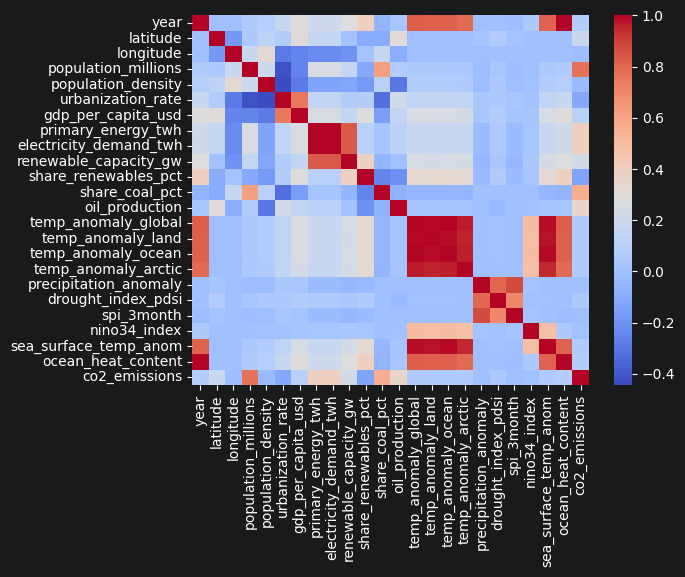

In [7]:
corr_matrix = df_cleaned.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap="coolwarm");

In [8]:
sorted_corr_target = corr_matrix[TARGET].sort_values(ascending=False, key=abs)
sorted_corr_target

co2_emissions             1.000000
population_millions       0.766923
share_coal_pct            0.564598
primary_energy_twh        0.394783
electricity_demand_twh    0.394783
oil_production            0.344945
renewable_capacity_gw     0.215388
latitude                  0.180420
share_renewables_pct     -0.132446
urbanization_rate        -0.113912
gdp_per_capita_usd        0.098381
year                      0.083329
ocean_heat_content        0.083108
temp_anomaly_ocean        0.069262
temp_anomaly_land         0.068725
sea_surface_temp_anom     0.068627
temp_anomaly_global       0.067878
temp_anomaly_arctic       0.064009
drought_index_pdsi        0.051349
population_density       -0.026515
longitude                -0.013083
spi_3month               -0.004862
nino34_index              0.003032
precipitation_anomaly    -0.000451
Name: co2_emissions, dtype: float64

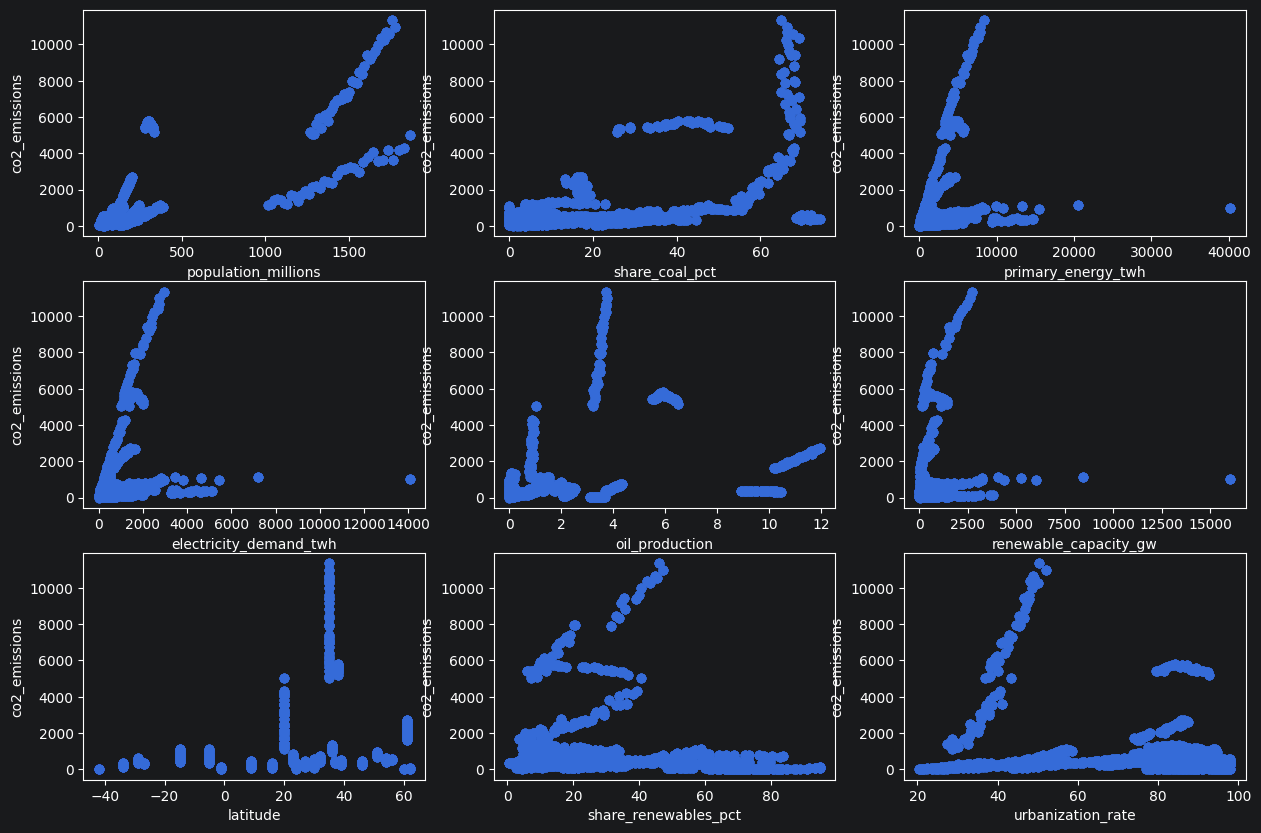

In [9]:
top9_cols = sorted_corr_target[1:10].index

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(top9_cols):
    axes[i].scatter(df_cleaned[col], df_cleaned[TARGET], alpha=0.6)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)

## Features and Target Preparation

In [10]:
class OrdinalEncoder:
    def __init__(self, *, unknown_value=-1, unknown_key="<unk>"):
        self.categories_ = []
        self.features_ = None
        self._mappings = []
        self._inv_mappings = []
        if unknown_value >= 0:
            raise ValueError("unknown_value must be negative to avoid valid-code collisions.")
        self.unknown_value_ = unknown_value
        self.unknown_key_ = unknown_key

    def fit(self, X):
        self.categories_ = []
        self.features_ = X.columns
        self._mappings = []
        self._inv_mappings = []

        for col in range(len(X.columns)):
            col_categories = pd.unique(X.iloc[:, col])

            self.categories_.append(col_categories)

            mapping, inv_mapping = {}, {}
            for idx, category in enumerate(col_categories):
                mapping[category] = idx
                inv_mapping[idx] = category
            inv_mapping[-1] = self.unknown_key_

            self._mappings.append(mapping)
            self._inv_mappings.append(inv_mapping)
        return self

    def _t(self, X, mappings, na_fill_value):
        if not self.categories_:
            raise ValueError("Encoder has not been fitted.")
        if self.features_ is None or not self.features_.equals(X.columns):
            raise ValueError("Columns does not match fitted data.")

        X = X.copy()
        for i, col in enumerate(X.columns):
            X[col] = X[col].map(mappings[i]).fillna(na_fill_value)
        return X

    def transform(self, X):
        return self._t(X, self._mappings, self.unknown_value_).astype(int)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X):
        return self._t(X, self._inv_mappings, self.unknown_key_)

The predictor variables are standardized using z-score normalization,

$$
z = \frac{x - \mu}{\sigma},
$$

where $x$ is the original feature value, $\mu$ is the mean, and $\sigma$ is the standard deviation computed from the training set. The same scaling parameters are then applied to the test set to ensure consistent feature scaling during model evaluation.

In [11]:
class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        self.features_ = None

    def fit(self, X):
        self.mean_ = X.mean()
        self.std_ = X.std()
        self.features_ = X.columns
        return self

    def _check(self, X):
        if self.mean_ is None or self.std_ is None:
            raise ValueError("Encoder has not been fitted.")
        if self.features_ is None or not self.features_.equals(X.columns):
            raise ValueError("Columns does not match fitted data.")

    def transform(self, X):
        self._check(X)
        X = X.copy()
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X):
        self._check(X)
        X = X.copy()
        return X * self.std_ + self.mean_

In [12]:
numerical_features = df_cleaned.select_dtypes(include="number").columns
categorical_features = df_cleaned.select_dtypes(exclude="number").columns

numerical_features, categorical_features

(Index(['year', 'latitude', 'longitude', 'population_millions',
        'population_density', 'urbanization_rate', 'gdp_per_capita_usd',
        'primary_energy_twh', 'electricity_demand_twh', 'renewable_capacity_gw',
        'share_renewables_pct', 'share_coal_pct', 'oil_production',
        'temp_anomaly_global', 'temp_anomaly_land', 'temp_anomaly_ocean',
        'temp_anomaly_arctic', 'precipitation_anomaly', 'drought_index_pdsi',
        'spi_3month', 'nino34_index', 'sea_surface_temp_anom',
        'ocean_heat_content', 'co2_emissions'],
       dtype='str'),
 Index(['country', 'continent', 'income_group', 'latitude_band',
        'climate_zone'],
       dtype='str'))

In [13]:
df_train, df_test = df_cleaned[df_cleaned["year"] < 2010], df_cleaned[df_cleaned["year"] >= 2010]

df_train.shape, df_test.shape

((6096, 29), (4921, 29))

In [14]:
oe = OrdinalEncoder()
df_train[categorical_features] = oe.fit_transform(df_train[categorical_features])
df_test[categorical_features] = oe.transform(df_test[categorical_features])

ss = StandardScaler()
df_train[numerical_features] = ss.fit_transform(df_train[numerical_features])
df_test[numerical_features] = ss.transform(df_test[numerical_features])

## Building Model: Linear Regression

The exploratory analysis indicates that several predictor variables have approximately linear relationships with PoU. Therefore, **linear regression** is adopted to model PoU as a function of the selected predictors.

The linear regression model represents PoU as a linear combination of the predictor variables. For an observation $\mathbf{x}^{(i)}$, the prediction is

$$
\hat{y}^{(i)}
=
w_0+\sum_{j=1}^{p}w_jx_j^{(i)},
$$

where $w_0$ is the intercept, $w_j$ is the coefficient of the $j$-th predictor, and $p$ is the number of predictors. By augmenting the feature matrix with a column of ones, the bias term is incorporated into the weight vector. Let $\tilde{\mathbf X}$ denote the augmented feature matrix. The model can then be written compactly as

$$
\hat{\mathbf y}
=
\tilde{\mathbf X}\mathbf w.
$$

where $\tilde{\mathbf X}$ is the input matrix with a leading column of ones.

The model is trained by minimizing the **mean squared error (MSE)** cost function,

$$
J(\mathbf w)
=
\frac{1}{2n}
\sum_{i=1}^{n}
\left(
\hat y^{(i)}
-
y^{(i)}
\right)^2,
$$

where $n$ is the number of training observations.

This can be expressed in matrix form as

$$
\begin{aligned}
J(\mathbf w)
&=
\frac{1}{2n}
(\mathbf y-\tilde{\mathbf X}\mathbf w)^\top
(\mathbf y-\tilde{\mathbf X}\mathbf w) \\
&=
\frac{1}{2n}
(\mathbf y^\top-\mathbf w^\top\tilde{\mathbf X}^\top)
(\mathbf y-\tilde{\mathbf X}\mathbf w) \\
&=
\frac{1}{2n}
\left(
\mathbf y^\top\mathbf y
-
\mathbf y^\top\tilde{\mathbf X}\mathbf w
-
\mathbf w^\top\tilde{\mathbf X}^\top\mathbf y
+
\mathbf w^\top\tilde{\mathbf X}^\top\tilde{\mathbf X}\mathbf w
\right).
\end{aligned}
$$

Differentiating with respect to $\mathbf w$ gives

$$
\begin{aligned}
\nabla_{\mathbf w}J(\mathbf w)
&=
\frac{1}{2n}
\left(
0
-
(\mathbf y^\top\tilde{\mathbf X})^\top
-
\tilde{\mathbf X}^\top\mathbf y
+
2\tilde{\mathbf X}^\top\tilde{\mathbf X}\mathbf w
\right) \\
&=
\frac{1}{n}
\left(
-
\tilde{\mathbf X}^\top\mathbf y
+
\tilde{\mathbf X}^\top\hat{\mathbf y}
\right) \\
&=
\frac{1}{n}
\tilde{\mathbf X}^\top
(\hat{\mathbf y}-\mathbf y).
\end{aligned}
$$

Instead of solving for the optimal coefficients analytically, the model is trained using batch gradient descent (BGD). The coefficients are initialized to zero and updated iteratively according to

$$
\mathbf w
\leftarrow
\mathbf w
-
\alpha
\nabla_{\mathbf w}J(\mathbf w),
$$

where $\alpha$ is the learning rate. At each iteration, the gradient is computed using the entire training set, and the cost is recorded in `history_` to monitor convergence.

In [15]:
class LinearRegression:
    def __init__(self, lr=0.001, n_iters=5000):
        self.lr_ = lr
        self.n_iters_ = n_iters
        self.weights_ = None
        self.history_ = []

    def _predict(self, X):
        return (X @ self.weights_).squeeze()

    def predict(self, X):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))
        return self._predict(X)

    def _cost(self, X, y):
        n_samples, n_features = X.shape
        y_hat = self._predict(X)
        return (1 / (2 * n_samples)) * np.sum((y_hat - y) ** 2)

    def _cost_grad(self, X, y):
        n_samples, n_features = X.shape
        y_hat = self._predict(X)
        return (1 / n_samples) * X.T @ (y_hat - y)

    def fit(self, X, y):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))

        n_samples, n_features = X.shape
        self.weights_ = np.zeros((n_features,))
        self.history_ = []

        for _ in range(self.n_iters_):
            self.weights_ -= self.lr_ * self._cost_grad(X, y)

            cost = self._cost(X, y)
            self.history_.append(cost)

        return self

In [16]:
X_train, y_train = df_train[FEATURES].to_numpy(), df_train[TARGET].to_numpy()
X_test, y_test = df_test[FEATURES].to_numpy(), df_test[TARGET].to_numpy()

In [17]:
lr = LinearRegression(n_iters=10000)
lr.fit(X_train, y_train)

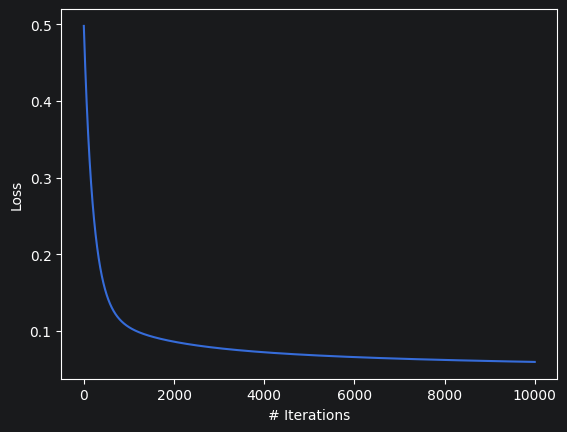

In [18]:
sns.lineplot(lr.history_)
plt.xlabel("# Iterations")
plt.ylabel("Loss");

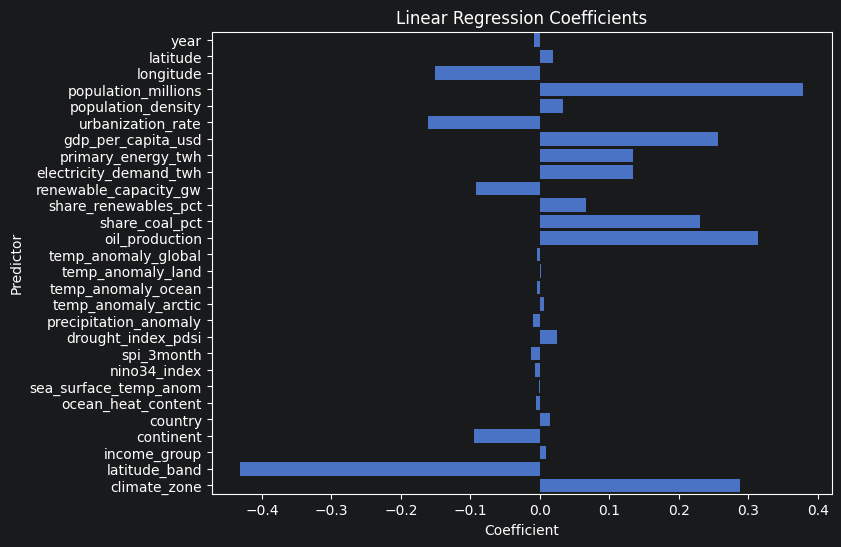

In [19]:
feature_weight_pairs = list(zip(FEATURES, lr.weights_.tolist()[1:]))
coef_df = pd.DataFrame(feature_weight_pairs, columns=["Feature", "Weight"])

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x="Weight", y="Feature")
plt.xlabel("Coefficient")
plt.ylabel("Predictor")
plt.title(f"Linear Regression Coefficients");

## Model Evaluation

To assess the predictive performance of the model, two evaluation metrics are used: the **coefficient of determination ($R^2$)** and the **Root Mean Squared Error (RMSE)**.

The coefficient of determination is defined as

$$
R^2
=
1
-
\frac{\sum_{i=1}^{n}(y^{(i)}-\hat{y}^{(i)})^2}
{\sum_{i=1}^{n}(y^{(i)}-\bar{y})^2},
$$

where $\bar{y}$ is the mean of the observed PoU values. The $R^2$ score measures the proportion of variance in PoU explained by the model, with values closer to 1 indicating a better fit.

In [20]:
y_pred = lr.predict(X_test)

In [21]:
def r2_score(y_true, y_pred):
    return float(1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true, axis=0)) ** 2))

The RMSE is defined as

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(y^{(i)}-\hat{y}^{(i)}\right)^2
},
$$

where $n$ is the number of test observations. RMSE measures the average prediction error in the same units as the response variable, making it easier to interpret. Lower RMSE values indicate better predictive performance.

In [22]:
def root_mean_squared_error(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2).tolist())

The model is evaluated on the test set using these metrics. A higher $R^2$ and a lower RMSE indicate better predictive performance and stronger generalization to unseen data.

In [23]:
r2_score(y_test, y_pred), root_mean_squared_error(y_test, y_pred)

(0.8187328406952551, 0.3160552989025188)

## Improving the Model: Multilayer Perceptron

To improve the predictive performance of the model, a **multilayer perceptron (MLP)** is implemented. Unlike linear regression, an MLP is capable of learning complex nonlinear relationships between the predictors and the target through multiple layers of nonlinear transformations. This enables the model to capture patterns that cannot be represented by a linear model.

An MLP network consists of a sequence of dense layers separated by nonlinear activation functions.


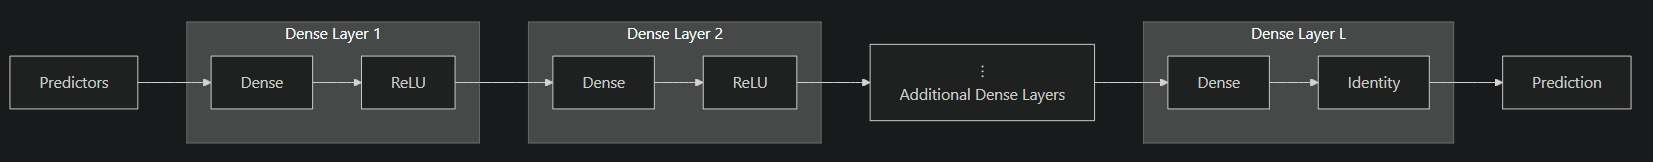



**Forward propagation.** During the forward pass, the input data are propagated sequentially through each layer.

Let $\mathbf a^{(0)}=\mathbf X$ denote the input feature matrix. For the $l$-th dense layer, the pre-activation values are computed as

$$
\mathbf z^{(l)}
=
\tilde{\mathbf A}^{(l-1)}
\mathbf W^{(l)\top},
$$

where $\tilde{\mathbf A}^{(l-1)}$ denotes the output of the previous layer augmented with a column of ones to incorporate the bias term, and $\mathbf W^{(l)}$ is the corresponding weight matrix.

The output of the layer is then obtained by applying an activation function,

$$
\mathbf a^{(l)}
=
f\!\left(
\mathbf z^{(l)}
\right).
$$

For the hidden layers, the Rectified Linear Unit (ReLU) activation function is used,

$$
f(z)=\max(0,z),
$$

whereas the output layer uses the identity function,

$$
f(z)=z.
$$

If the network contains $L$ layers, the final prediction is $\hat{\mathbf y}=\mathbf a^{(L)}$.

**Backward propagation.** The network parameters are optimized using the backpropagation algorithm together with BGD. Backpropagation computes the gradients of the loss with respect to every learnable parameter by repeatedly applying the chain rule from the output layer towards the input layer.

For the output layer, the identity activation function has derivative

$$
\frac{d}{dz}z=1,
$$

and therefore

$$
\delta^{(L)}
=
\frac{\partial J}{\partial\hat{\mathbf y}},
$$

where $\delta^{(l)}=\frac{\partial J}{\partial\mathbf z^{(l)}}$ denotes the error signal of the $l$-th layer.

For a fully connected layer, $\mathbf z^{(l)}=\tilde{\mathbf A}^{(l-1)}\mathbf W^{(l)\top}$, the chain rule gives

$$
\begin{aligned}
\frac{\partial J}{\partial\mathbf W^{(l)}}
&=
\frac{\partial J}{\partial\mathbf z^{(l)}}
\frac{\partial\mathbf z^{(l)}}{\partial\mathbf W^{(l)}} \\
&=
\delta^{(l)\top}
\tilde{\mathbf A}^{(l-1)}.
\end{aligned}
$$

Similarly, the error propagated to the previous layer is

$$
\begin{aligned}
\frac{\partial J}{\partial\mathbf A^{(l-1)}}
&=
\frac{\partial J}{\partial\mathbf z^{(l)}}
\frac{\partial\mathbf z^{(l)}}{\partial\mathbf A^{(l-1)}} \\
&=
\delta^{(l)}
\mathbf W^{(l)},
\end{aligned}
$$

where the first column corresponding to the bias weights is excluded because the bias input is constant.

For each hidden layer, the ReLU activation introduces an additional derivative. Since

$$
f(z)=\max(0,z),
$$

its derivative is

$$
f'(z)
=
\begin{cases}
1,&z>0,\\
0,&z\le0.
\end{cases}
$$

Applying the chain rule gives

$$
\delta^{(l)}
=
\left(
\delta^{(l+1)}
\mathbf W^{(l+1)}
\right)
\odot
f'(\mathbf z^{(l)}),
$$

where $\odot$ denotes element-wise multiplication. Consequently, neurons whose pre-activation values are non-positive do not contribute to the gradients during backpropagation.

**Parameter update.** After the gradients have been computed for every learnable layer, the weights are updated using batch gradient descent,

$$
\mathbf W^{(l)}
\leftarrow
\mathbf W^{(l)}
-
\alpha
\frac{\partial J}{\partial\mathbf W^{(l)}},
$$

where $\alpha$ is the learning rate.

The gradients are computed using the entire training set before each update, and the forward propagation, backpropagation, and weight update steps are repeated until the specified number of training iterations is reached.

In [24]:
class LinearRegressionLayer:
    def __init__(self, n_in, n_out, random_state=None):
        self.learnable_ = True
        self.random_state = random_state
        self.input_ = None
        self.weights_gradient_ = None
        rng = np.random.default_rng(random_state)
        self.weights_ = rng.standard_normal((n_out, n_in + 1)) * np.sqrt(2 / n_in)

    def forward(self, X):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))
        self.input_ = X  # (n_samples, n_in + 1)
        return X @ self.weights_.T  # (n_samples, n_out)

    def backward(self, delta):  # (n_samples, n_out)
        self.weights_gradient_ = delta.T @ self.input_  # (n_out, n_in + 1)
        # Differentiate bias terms get 0
        return delta @ self.weights_[:, 1:]  # (n_samples, n_in)

The weights of each dense layer are initialized using **He initialization**, in which the weights are sampled from a zero-mean normal distribution with variance $2/n_{\text{in}}$. This initialization is well suited to networks with ReLU activation functions and helps maintain stable activation and gradient magnitudes during training.

In preliminary experiments, zero initialization was also evaluated. However, the model produced near-zero predictions and achieved a very low test $R^2$. Since all weights were initialized identically, the hidden neurons produced identical zero activations, which were then suppressed by the ReLU activation function. This prevented effective gradient propagation and weight updates, causing the network to fail to learn.

In [25]:
class Relu:
    def __init__(self):
        self.learnable_ = False
        self.input_ = None

    def forward(self, X):  # (n_samples, n_in)
        self.input_ = X
        return np.maximum(0, X)

    def backward(self, delta):  # (n_samples, n_out)
        delta_relu = self.input_ > 0  # (n_samples, n_in)
        return delta * delta_relu  # Element-wise, n_in == n_out

In [26]:
class RegressiveMultilayerPerceptron:
    def __init__(self, layers, lr=0.001, n_iters=5000):
        self.lr_ = lr
        self.n_iters_ = n_iters
        self.layers_ = layers
        self.history_ = []

    def predict(self, X):
        cur = X
        for layer in self.layers_:
            cur = layer.forward(cur)
        return cur.squeeze(-1)  # (n_samples,)

    def _cost(self, X, y):  # Same as single layer
        n_samples, _ = X.shape
        y_hat = self.predict(X)
        return (1 / (2 * n_samples)) * np.sum((y_hat - y) ** 2)

    def _cost_grad_wrt_pred(self, X, y):
        n_samples, _ = X.shape
        y_hat = self.predict(X)
        return np.expand_dims((y_hat - y) / n_samples, axis=-1)  # (n_samples, 1)

    def _backpropagate(self, X, y):
        delta = self._cost_grad_wrt_pred(X, y)

        for layer in self.layers_[::-1]:
            delta = layer.backward(delta)
            if layer.learnable_:
                layer.weights_ -= self.lr_ * layer.weights_gradient_

    def fit(self, X, y):
        self.history_ = []

        for _ in range(self.n_iters_):
            self._backpropagate(X, y)

            cost = self._cost(X, y)
            self.history_.append(cost)

In [27]:
mlp = RegressiveMultilayerPerceptron([
    LinearRegressionLayer(X_train.shape[1], 32, random_state=42),
    Relu(),
    LinearRegressionLayer(32, 16, random_state=42),
    Relu(),
    LinearRegressionLayer(16, 1, random_state=42),
], lr=0.001, n_iters=50000)
mlp.fit(X_train, y_train)

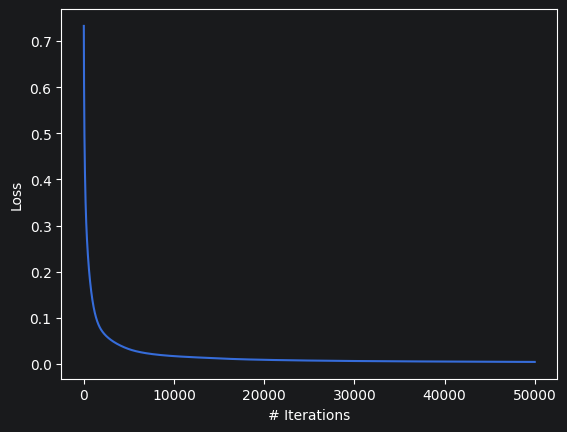

In [28]:
sns.lineplot(mlp.history_)
plt.xlabel("# Iterations")
plt.ylabel("Loss");

In [29]:
y_pred_mlp = mlp.predict(X_test)

r2_score(y_test, y_pred_mlp), root_mean_squared_error(y_test, y_pred_mlp)

(0.8815855032686737, 0.20646613155056504)

This shows an improvement over the linear regression model.